## 1. Install libraries

In [0]:
# Install required libraries
%pip install snowflake-connector-python pandas scikit-learn python-dotenv -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
msal 1.34.0 requires cryptography<49,>=2.5, but you have cryptography 50.0.0 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


##2. Import libraries and connect to Snowflake

In [0]:
import snowflake.connector as sf
import pandas as pd
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Your Snowflake credentials
account = 'JLYVKVC-PD30052'
user = 'GRAVEN66'
warehouse = 'COMPUTE_WH'
database = 'URL_DATABASE'
schema = 'DBT_FGRAVLUND'

# Get password from .env file
password = os.getenv("SNOWFLAKE_PASSWORD")

# Check if password exists
if not password:
    raise ValueError("SNOWFLAKE_PASSWORD not found in .env file! Please add it.")

# Create connection
conn = sf.connect(
    account=account,
    user=user,
    password=password,
    warehouse=warehouse,
    database=database,
    schema=schema
)

print("Successfully connected to Snowflake!")

Successfully connected to Snowflake!


##3. Load data from Snowflake and examine

In [0]:
import pandas as pd

print("=" * 60)
print("STEP 1: LOAD DATA FROM SNOWFLAKE")
print("=" * 60)

# Query your table
query = "SELECT * FROM FCT_PHISHING_URL;"

# Load into DataFrame
df = pd.read_sql(query, conn)

print(f"✓ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

print("\n" + "=" * 60)
print("STEP 2: EXAMINE THE DATA")
print("=" * 60)

# Show first 5 rows
print("\n--- First 5 rows ---")
display(df.head())

# Show label distribution (viktigast!)
print("\n--- Label distribution ---")
print(f"Phishing (1): {df['LABEL_BINARY'].sum():,} ({df['LABEL_BINARY'].mean():.1%})")
print(f"Legitimate (0): {len(df) - df['LABEL_BINARY'].sum():,} ({(1 - df['LABEL_BINARY'].mean()):.1%})")

print("\n" + "=" * 60)
print("DATA IS READY FOR MACHINE LEARNING")
print("=" * 60)

STEP 1: LOAD DATA FROM SNOWFLAKE


/home/spark-17b38b06-352b-42a4-84b9-93/.ipykernel/83/command-5402711149543554-539632870:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✓ Dataset loaded: 579,920 rows, 80 columns

STEP 2: EXAMINE THE DATA

--- First 5 rows ---


URL_IDENTIFIER,LABEL_BINARY,URL_LENGTH,DOMAIN_LENGTH,HOSTNAME_LENGTH,PATH_LENGTH,FIRST_DIR_LENGTH,TLD_LENGTH,TLD_LENGTH_DOMAIN,URL_DEPTH,QUERY_LENGTH,PATH_SEGMENTS_COUNT,NUM_DIGITS,NUM_LETTERS,NUM_SPECIAL_CHARS,NUM_DOTS,NUM_HYPHENS,NUM_AT,NUM_PERCENT,NUM_EQUALS,NUM_QUESTION,NUM_AMPERSAND,NUM_HASH,NUM_UNDERSCORE,NUM_SPECIAL,NUM_SLASH,NUM_PARAMS,ENTROPY_URL,ENTROPY_HOSTNAME,ENTROPY_DOMAIN,ENTROPY_PATH,QUERY_ENTROPY,RATIO_DIGITS,RATIO_LETTERS,RATIO_SPECIAL_CHARS,UPPERCASE_RATIO,LOWERCASE_RATIO,IS_IP_ADDRESS,STARTS_WITH_IP,IS_SUSPICIOUS_TLD,USES_HTTPS,HAS_WWW,UNUSUAL_DOUBLE_SLASH,MULTIPLE_HTTP,CONTAINS_PORT_NUMBER,PATH_HAS_ENCODED_CHARS,QUERY_HAS_BASE64,CONTAINS_LOGIN,CONTAINS_SECURE,CONTAINS_VERIFY,CONTAINS_ACCOUNT,CONTAINS_UPDATE,CONTAINS_BANK,CONTAINS_CLOUD,CONTAINS_BRAND,QUERY_KEY_COUNT,QUERY_VALUE_LENGTH_AVG,SUCCESS,DNS_RESOLVES,HAS_MX_RECORD,HAS_TXT_RECORD,HAS_NS_RECORD,TTL_VALUE,IP_COUNT,CNAME_COUNT,RESOLVES_TO_PRIVATE_IP,WHOIS_SUCCESS,DOMAIN_AGE_DAYS,EXPIRATION_DAYS,CREATION_YEAR,DOMAIN_IS_RECENT,DOMAIN_REGISTERED_BEFORE_2020,REGISTRAR_VALID,NAME_SERVERS_COUNT,IS_PRIVACY_PROTECTED,WHOIS_MISSING,SUSPICIOUS_CHAR_COUNT,TOTAL_ENTROPY,RISK_CATEGORY,RISK_SCORE
https://postie.com/e-book/holiday-mail-that-converts-your-2025-bfcm-planing-guide/,0,82,6,10,64,6,3,3,2,0,2,4,62,16,1,9,0,0,0,0,0,0,0,16,5,0,4.525916907840902,3.121928094887362,2.584962500721156,4.43885307815258,0.0,0.048780487804878,0.7560975609756098,0.1951219512195122,0.0,0.7560975609756098,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,1.0,1.0,1.0,60.0,1.0,0.0,0.0,1.0,10759.0,196.0,1996.0,0.0,1.0,1.0,4.0,0.0,0.0,29,11.549732486714637,legitimate,0
https://postighq.com/,1,21,8,12,1,0,3,3,0,0,0,0,16,5,1,0,0,0,0,0,0,0,0,5,3,0,3.5585186130489053,3.418295834054489,3.0,0.0,0.0,0.0,0.7619047619047619,0.238095238095238,0.0,0.7619047619047619,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,549.0,1.0,0.0,0.0,1.0,399.0,-35.0,2024.0,0.0,0.0,1.0,3.0,0.0,0.0,5,6.558518613048905,phishing,1
https://postila.ru/post/category/news,0,37,7,10,19,4,2,2,3,0,3,0,30,7,1,0,0,0,0,0,0,0,0,7,5,0,3.94650590743434,3.321928094887362,2.807354922057604,3.576617644908665,0.0,0.0,0.8108108108108109,0.1891891891891892,0.0,0.8108108108108109,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,1.0,1.0,1.0,537.0,1.0,0.0,0.0,1.0,4707.0,405.0,2013.0,0.0,1.0,1.0,4.0,0.0,0.0,7,10.330478474400609,legitimate,0
https://postimages.org/plugins/smf,0,34,10,14,12,7,3,3,2,0,2,0,28,6,1,0,0,0,0,0,0,0,0,6,4,0,3.9146892241642446,3.378783493486176,3.121928094887362,3.2516291673878226,0.0,0.0,0.8235294117647058,0.1764705882352941,0.0,0.8235294117647058,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0,1.0,1.0,300.0,1.0,0.0,0.0,1.0,5443.0,35.0,2010.0,0.0,1.0,1.0,2.0,0.0,0.0,6,10.28824648643943,legitimate,0
https://postirs.com/,1,20,7,11,1,0,3,3,0,0,0,0,15,5,1,0,0,0,0,0,0,0,0,5,3,0,3.4086949695628417,3.0957952550009344,2.5216406363433186,0.0,0.0,0.0,0.75,0.25,0.0,0.75,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,550.0,1.0,0.0,0.0,1.0,399.0,-35.0,2024.0,0.0,0.0,1.0,3.0,0.0,0.0,5,5.93033560590616,phishing,1



--- Label distribution ---
Phishing (1): 241,281 (41.6%)
Legitimate (0): 338,639 (58.4%)

DATA IS READY FOR MACHINE LEARNING


##4. Prepare data for ML

In [0]:
from sklearn.model_selection import train_test_split

print("=" * 60)
print("PREPARE DATA FOR MACHINE LEARNING")
print("=" * 60)

# Specify the label column (the column we want to predict)
label_col = "LABEL_BINARY"
print(f"Label column: {label_col}")

# 1. Clean data
before = len(df)
df = df.drop_duplicates()
df = df.dropna()
print(f"Removed {before - len(df)} duplicate rows")

# 2. Remove DATA LEAKAGE column
if 'RISK_SCORE' in df.columns:
    df = df.drop(columns=['RISK_SCORE'])
    print("✓ Removed 'RISK_SCORE' ")

# 3. Remove text columns (can't use raw text for ML)
text_cols = [col for col in df.columns if col != label_col and df[col].dtype == 'object']
if text_cols:
    df = df.drop(columns=text_cols)
    print(f"✓ Removed text columns")

# 4. Separate features (X) and labels (y)
X = df.drop(columns=[label_col])
y = df[label_col]

# 5. Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Summary
print(f"\n✓ Dataset: {df.shape[0]:,} rows, {df.shape[1]} features")
print(f"✓ Phishing: {y.sum():,} ({y.mean():.1%})")
print(f"✓ Training: {X_train.shape[0]:,} rows")
print(f"✓ Test: {X_test.shape[0]:,} rows")

print("\n" + "=" * 60)
print("DATA READY")
print("=" * 60)

PREPARE DATA FOR MACHINE LEARNING
Label column: LABEL_BINARY
Removed 11 duplicate rows
✓ Removed 'RISK_SCORE' 
✓ Removed text columns

✓ Dataset: 579,909 rows, 77 features
✓ Phishing: 240,846 (41.5%)
✓ Training: 463,927 rows
✓ Test: 115,982 rows

DATA READY


##5. Train one supervised model and one unsupervised model

In [0]:
import mlflow
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score

print("=" * 60)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 60)

mlflow_email = os.getenv("MLFLOW_EXPERIMENT_EMAIL")
mlflow.set_experiment(f"/Users/{mlflow_email}/phishing_detection_experiment")

# ============================================================
# Model 1: Random Forest (supervised)
# ============================================================
print("\n--- MODEL 1: Random Forest ---")
print("Type: Supervised learning")
print("Number of trees: 100")
print("Training...")

with mlflow.start_run(run_name="RandomForest_100trees") as run:
    # Log parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)

    # Train model
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_pred)

    # Calculate additional metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    precision_rf = precision_score(y_test, rf_pred)
    recall_rf = recall_score(y_test, rf_pred)
    f1_rf = f1_score(y_test, rf_pred)

    # Log metrics
    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", precision_rf)
    mlflow.log_metric("recall", recall_rf)
    mlflow.log_metric("f1_score", f1_rf)

    # Log the model
    mlflow.sklearn.log_model(rf, name="random_forest_model")

    print(f"Training complete!")
    print(f"Accuracy on test data: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# ============================================================
# Model 2: Isolation Forest (unsupervised)
# ============================================================
print("\n--- MODEL 2: Isolation Forest ---")
print("Type: Unsupervised learning (finds anomalies)")
print("Expected anomaly rate: 10%")
print("Training...")

with mlflow.start_run(run_name="IsolationForest_10percent") as run:
    # Log parameters
    mlflow.log_param("model_type", "Isolation Forest")
    mlflow.log_param("contamination", 0.1)
    mlflow.log_param("random_state", 42)

    # Train model
    iso = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
    iso.fit(X_train)
    iso_pred = iso.predict(X_test)
    iso_pred_binary = (iso_pred == -1).astype(int)
    iso_accuracy = accuracy_score(y_test, iso_pred_binary)

    # Log metrics
    mlflow.log_metric("accuracy", iso_accuracy)

    # Log the model
    mlflow.sklearn.log_model(iso, name="isolation_forest_model")

    print(f"Training complete!")
    print(f"Accuracy on test data: {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Random Forest:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Isolation Forest:  {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")
print(f"Difference:        {rf_accuracy - iso_accuracy:.4f} ({(rf_accuracy - iso_accuracy)*100:.2f}%)")

TRAINING MACHINE LEARNING MODELS

--- MODEL 1: Random Forest ---
Type: Supervised learning
Number of trees: 100
Training...


🔗 View Logged Model at: https://dbc-4a47f3f4-59ff.cloud.databricks.com/ml/experiments/3382046718875501/models/m-ce6c3deee4274c68aced12c5b5f5ba68?o=7474650823064672
2026/08/05 10:04:18 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Training complete!
Accuracy on test data: 0.9845 (98.45%)

--- MODEL 2: Isolation Forest ---
Type: Unsupervised learning (finds anomalies)
Expected anomaly rate: 10%
Training...


🔗 View Logged Model at: https://dbc-4a47f3f4-59ff.cloud.databricks.com/ml/experiments/3382046718875501/models/m-ea9f40a450064880bfb3a3d80a670d81?o=7474650823064672
2026/08/05 10:04:31 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Training complete!
Accuracy on test data: 0.6266 (62.66%)

SUMMARY
Random Forest:     0.9845 (98.45%)
Isolation Forest:  0.6266 (62.66%)
Difference:        0.3579 (35.79%)


##6. Visualizations and evaluation 

EVALUATION OF BOTH MODELS

RANDOM FOREST
Precision: 0.9903 (99.03%)
Recall:    0.9723 (97.23%)
F1-score:  0.9812 (98.12%)
Accuracy:  0.9845 (98.45%)


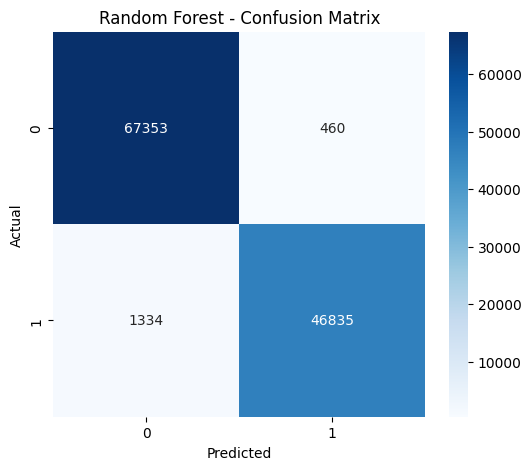


ISOLATION FOREST
Precision: 0.7099 (70.99%)
Recall:    0.1708 (17.08%)
F1-score:  0.2753 (27.53%)
Accuracy:  0.6266 (62.66%)


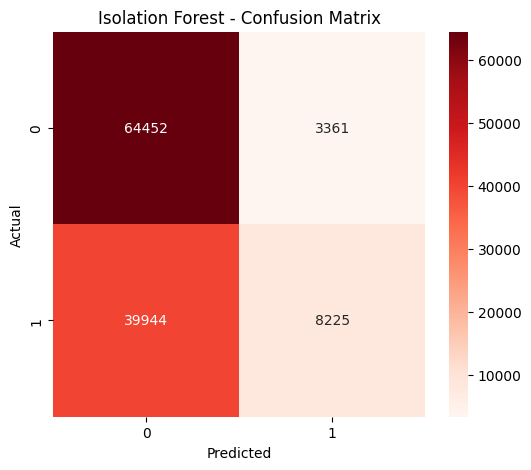


MOST IMPORTANT FEATURES


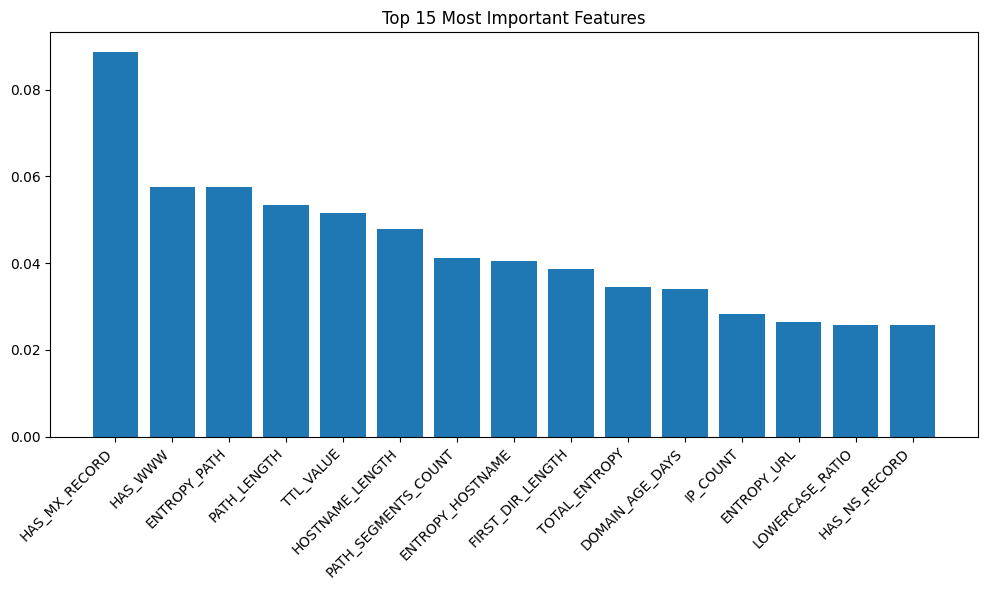


--- TOP 5 FEATURES ---
1. HAS_MX_RECORD: 8.88%
2. HAS_WWW: 5.76%
3. ENTROPY_PATH: 5.75%
4. PATH_LENGTH: 5.33%
5. TTL_VALUE: 5.16%


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("=" * 60)
print("EVALUATION OF BOTH MODELS")
print("=" * 60)

# ============================================================
# 1. RANDOM FOREST EVALUATION
# ============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Calculate metrics
precision_rf = precision_score(y_test, rf_pred)
recall_rf = recall_score(y_test, rf_pred)
f1_rf = f1_score(y_test, rf_pred)

print(f"Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-score:  {f1_rf:.4f} ({f1_rf*100:.2f}%)")
print(f"Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================================
# 2. ISOLATION FOREST EVALUATION
# ============================================================
print("\n" + "=" * 60)
print("ISOLATION FOREST")
print("=" * 60)

precision_iso = precision_score(y_test, iso_pred_binary)
recall_iso = recall_score(y_test, iso_pred_binary)
f1_iso = f1_score(y_test, iso_pred_binary)

print(f"Precision: {precision_iso:.4f} ({precision_iso*100:.2f}%)")
print(f"Recall:    {recall_iso:.4f} ({recall_iso*100:.2f}%)")
print(f"F1-score:  {f1_iso:.4f} ({f1_iso*100:.2f}%)")
print(f"Accuracy:  {iso_accuracy:.4f} ({iso_accuracy*100:.2f}%)")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_iso = confusion_matrix(y_test, iso_pred_binary)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Reds')
plt.title('Isolation Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================================
# 3. FEATURE IMPORTANCE (Random Forest)
# ============================================================
print("\n" + "=" * 60)
print("MOST IMPORTANT FEATURES")
print("=" * 60)

importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

# Top 5 features
print("\n--- TOP 5 FEATURES ---")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.2%}")

## 7. Pipeline - Isolation Forest → Random Forest

In [0]:
print("=" * 60)
print("PIPELINE: Isolation Forest → Random Forest")
print("=" * 60)

# ============================================================
# STEP 1: Isolation Forest finds suspicious URLs
# ============================================================
print("\n--- STEP 1: Isolation Forest flags unusual URLs ---")

# Train Isolation Forest as a filter
iso_pipeline = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso_pipeline.fit(X_train)

# Predict on test data
anomalies = iso_pipeline.predict(X_test)

# Get only the suspicious URLs (where prediction = -1)
suspicious_index = [i for i, val in enumerate(anomalies) if val == -1]
X_suspicious = X_test.iloc[suspicious_index]
y_suspicious = y_test.iloc[suspicious_index]

print(f"Isolation Forest flagged {len(suspicious_index):,} URLs as suspicious")
print(f"  Of these, {y_suspicious.sum():,} were actually phishing")

# ============================================================
# STEP 2: Random Forest analyzes ONLY suspicious URLs
# ============================================================
print("\n--- STEP 2: Random Forest analyzes ONLY suspicious URLs ---")

# Use the already trained Random Forest on suspicious URLs
rf_pred_suspicious = rf.predict(X_suspicious)
accuracy_on_suspicious = accuracy_score(y_suspicious, rf_pred_suspicious)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score
precision_pipe = precision_score(y_suspicious, rf_pred_suspicious)
recall_pipe = recall_score(y_suspicious, rf_pred_suspicious)
f1_pipe = f1_score(y_suspicious, rf_pred_suspicious)

# ============================================================
# LOG TO MLflow
# ============================================================
print("\n--- Logging to MLflow ---")

mlflow.set_experiment(f"/Users/{mlflow_email}/phishing_detection_experiment")

with mlflow.start_run(run_name="Pipeline_Isolation_RF"):
    # Log parameters
    mlflow.log_param("model_type", "Pipeline (Isolation Forest → Random Forest)")
    mlflow.log_param("contamination", 0.1)
    mlflow.log_param("n_estimators_rf", 100)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy_on_suspicious)
    mlflow.log_metric("precision", precision_pipe)
    mlflow.log_metric("recall", recall_pipe)
    mlflow.log_metric("f1_score", f1_pipe)

    # Log the model
    mlflow.sklearn.log_model(rf, name="pipeline_model")

print("✓ Pipeline logged to MLflow")

# ============================================================
# RESULTS
# ============================================================
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Random Forest on ALL test data:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Random Forest on ONLY suspicious:  {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)")

# Filtering effectiveness
phishing_percentage_suspicious = y_suspicious.sum() / len(y_suspicious)
phishing_percentage_total = y_test.sum() / len(y_test)

print("\n" + "=" * 60)
print("FILTERING EFFECTIVENESS")
print("=" * 60)
print(f"Phishing in entire test set:     {phishing_percentage_total:.2%}")
print(f"Phishing among suspicious URLs:  {phishing_percentage_suspicious:.2%}")
print(f"\n--> Isolation Forest concentrated phishing from {phishing_percentage_total:.2%} to {phishing_percentage_suspicious:.2%}!")

PIPELINE: Isolation Forest → Random Forest

--- STEP 1: Isolation Forest flags unusual URLs ---
Isolation Forest flagged 11,586 URLs as suspicious
  Of these, 8,225 were actually phishing

--- STEP 2: Random Forest analyzes ONLY suspicious URLs ---

--- Logging to MLflow ---


🔗 View Logged Model at: https://dbc-4a47f3f4-59ff.cloud.databricks.com/ml/experiments/3382046718875501/models/m-9e343f93df6a41f4b5bd8d406f7e8de8?o=7474650823064672
2026/08/05 10:05:07 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


✓ Pipeline logged to MLflow

RESULTS
Random Forest on ALL test data:     0.9845 (98.45%)
Random Forest on ONLY suspicious:  0.9881 (98.81%)

FILTERING EFFECTIVENESS
Phishing in entire test set:     41.53%
Phishing among suspicious URLs:  70.99%

--> Isolation Forest concentrated phishing from 41.53% to 70.99%!


##8. Comparison between Random Forest and Pipeline

PIPELINE EVALUATION

--- PIPELINE CONFUSION MATRIX ---


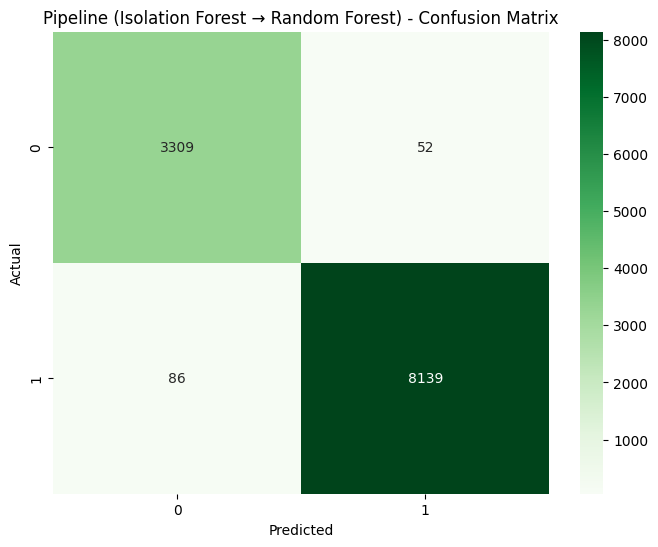

True Negatives:  3,309
False Positives: 52
False Negatives: 86
True Positives:  8,139

Pipeline Metrics:
  Precision: 0.9937 (99.37%)
  Recall:    0.9895 (98.95%)
  F1-score:  0.9916 (99.16%)
  Accuracy:  0.9881 (98.81%)

--- Logging to MLflow ---
✓ Pipeline metrics logged to MLflow


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("=" * 60)
print("PIPELINE EVALUATION")
print("=" * 60)

# ============================================================
# 1. PIPELINE CONFUSION MATRIX
# ============================================================
print("\n--- PIPELINE CONFUSION MATRIX ---")

# Create confusion matrix for pipeline
cm_pipeline = confusion_matrix(y_suspicious, rf_pred_suspicious)
tn_pipe, fp_pipe, fn_pipe, tp_pipe = cm_pipeline.ravel()

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Greens')
plt.title('Pipeline (Isolation Forest → Random Forest) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print the numbers
print(f"True Negatives:  {tn_pipe:,}")
print(f"False Positives: {fp_pipe:,}")
print(f"False Negatives: {fn_pipe:,}")
print(f"True Positives:  {tp_pipe:,}")

# ============================================================
# 2. PIPELINE METRICS
# ============================================================
precision_pipe = precision_score(y_suspicious, rf_pred_suspicious)
recall_pipe = recall_score(y_suspicious, rf_pred_suspicious)
f1_pipe = f1_score(y_suspicious, rf_pred_suspicious)

print(f"\nPipeline Metrics:")
print(f"  Precision: {precision_pipe:.4f} ({precision_pipe*100:.2f}%)")
print(f"  Recall:    {recall_pipe:.4f} ({recall_pipe*100:.2f}%)")
print(f"  F1-score:  {f1_pipe:.4f} ({f1_pipe*100:.2f}%)")
print(f"  Accuracy:  {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)")

# ============================================================
# 3. LOG TO MLflow
# ============================================================
print("\n--- Logging to MLflow ---")

mlflow.set_experiment(f"/Users/{mlflow_email}/phishing_detection_experiment")

with mlflow.start_run(run_name="Pipeline_Evaluation"):
    mlflow.log_param("model_type", "Pipeline (Isolation Forest → Random Forest)")
    mlflow.log_metric("accuracy", accuracy_on_suspicious)
    mlflow.log_metric("precision", precision_pipe)
    mlflow.log_metric("recall", recall_pipe)
    mlflow.log_metric("f1_score", f1_pipe)

print("✓ Pipeline metrics logged to MLflow")

##9. Overfitting test

In [0]:
from sklearn.metrics import accuracy_score

print("=" * 60)
print("OVERFITTING TEST")
print("=" * 60)

# ============================================================
# 1. RANDOM FOREST
# ============================================================
print("\n--- RANDOM FOREST ---")

# Training accuracy
train_pred_rf = rf.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, train_pred_rf)

# Test accuracy (already calculated)
print(f"Training: {train_accuracy_rf:.4f} ({train_accuracy_rf*100:.2f}%)")
print(f"Test:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

rf_diff = train_accuracy_rf - rf_accuracy
print(f"Difference: {rf_diff:.4f} ({rf_diff*100:.2f}%)")

# ============================================================
# 2. PIPELINE
# ============================================================
print("\n--- PIPELINE ---")

# Pipeline on training data
anomalies_train = iso_pipeline.predict(X_train)
suspicious_index_train = [i for i, val in enumerate(anomalies_train) if val == -1]
X_suspicious_train = X_train.iloc[suspicious_index_train]
y_suspicious_train = y_train.iloc[suspicious_index_train]

train_pred_pipeline = rf.predict(X_suspicious_train)
train_accuracy_pipeline = accuracy_score(y_suspicious_train, train_pred_pipeline)

pipeline_diff = train_accuracy_pipeline - accuracy_on_suspicious

print(f"Training: {train_accuracy_pipeline:.4f} ({train_accuracy_pipeline*100:.2f}%)")
print(f"Test:     {accuracy_on_suspicious:.4f} ({accuracy_on_suspicious*100:.2f}%)")
print(f"Difference: {pipeline_diff:.4f} ({pipeline_diff*100:.2f}%)")

# ============================================================
# 3. CONCLUSION
# ============================================================
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

# Random Forest
if rf_diff < 0.02:
    print(f"Random Forest: {rf_diff:.2%} difference - NOT overfitting")
else:
    print(f"Random Forest: {rf_diff:.2%} difference - COULD be overfitting")

# Pipeline
if pipeline_diff < 0.02:
    print(f"Pipeline: {pipeline_diff:.2%} difference - NOT overfitting")
else:
    print(f"Pipeline: {pipeline_diff:.2%} difference - COULD be overfitting")

# ============================================================
# 4. REFLECTION
# ============================================================
print("\n" + "=" * 60)
print("REFLECTION")
print("=" * 60)

print(f"""
Both models show small differences (<2%) between training and test accuracy.
This indicates the models generalize well and are NOT overfitting.

Note: 100% training accuracy is normal for Random Forest due to
bootstrap sampling and feature subsampling.

For complete certainty, the model should be tested on independent data
from a different source.
""")

OVERFITTING TEST

--- RANDOM FOREST ---
Training: 1.0000 (100.00%)
Test:     0.9845 (98.45%)
Difference: 0.0155 (1.55%)

--- PIPELINE ---
Training: 1.0000 (100.00%)
Test:     0.9881 (98.81%)
Difference: 0.0119 (1.19%)

CONCLUSION
Random Forest: 1.55% difference - NOT overfitting
Pipeline: 1.19% difference - NOT overfitting

REFLECTION

Both models show small differences (<2%) between training and test accuracy.
This indicates the models generalize well and are NOT overfitting.

Note: 100% training accuracy is normal for Random Forest due to
bootstrap sampling and feature subsampling.

For complete certainty, the model should be tested on independent data
from a different source.



# 10. Send ML results to Slack

In [0]:
import requests
import json
from dotenv import load_dotenv
import os

print("=" * 60)
print("SENDING RESULTS TO SLACK")
print("=" * 60)

# Load environment variables
load_dotenv()

# Get Slack Webhook URL
webhook_url = os.getenv("SLACK_WEBHOOK_URL")

if not webhook_url:
    raise ValueError("SLACK_WEBHOOK_URL not found in .env file!")

# Build Slack message
message = {
    "text": (
        "ML Pipeline Run Complete\n"
        "------------------------\n"
        "Best Model: Pipeline (Isolation Forest → Random Forest)\n"
        f"Accuracy: {accuracy_on_suspicious:.2%}\n"
        "------------------------\n"
        "Random Forest:\n"
        f"  Accuracy: {rf_accuracy:.2%}\n"
        f"  Precision: {precision_rf:.2%}\n"
        f"  Recall: {recall_rf:.2%}\n"
        f"  F1-score: {f1_rf:.2%}\n"
        "------------------------\n"
        "Pipeline:\n"
        f"  Accuracy: {accuracy_on_suspicious:.2%}\n"
        f"  Precision: {precision_pipe:.2%}\n"
        f"  Recall: {recall_pipe:.2%}\n"
        f"  F1-score: {f1_pipe:.2%}\n"
        "------------------------\n"
        f"Improvement: +{(accuracy_on_suspicious - rf_accuracy)*100:.2f} percentage points\n"
        "------------------------\n"
        "Model is ready for use."
    )
}

# Send message
response = requests.post(
    webhook_url,
    data=json.dumps(message),
    headers={'Content-Type': 'application/json'}
)

# Confirm
if response.status_code == 200:
    print("SUCCESS: Slack message sent!")
else:
    print(f"ERROR: Status code: {response.status_code}")

SENDING RESULTS TO SLACK
SUCCESS: Slack message sent!
